## 1. Load Preprocessed Training and Test Data

In this notebook, we start from the processed datasets created during the preprocessing stage. The features are already scaled/encoded, and the target column is `Machine failure`. We split the data into input features `X` and target labels `y` for model training and evaluation.

In [2]:
import pandas as pd

# Load preprocessed datasets
train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

# Separate features and target
X_train = train_df.drop(columns=["Machine failure"])
y_train = train_df["Machine failure"]

X_test = test_df.drop(columns=["Machine failure"])
y_test = test_df["Machine failure"]

# Check shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Check target distribution
print("\nTraining target distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (8000, 8)
y_train shape: (8000,)
X_test shape: (2000, 8)
y_test shape: (2000,)

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

Test target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


## 2. Create a Model Evaluation Function

Because the dataset is highly imbalanced, accuracy alone is not enough. A model could predict "no failure" almost all the time and still get around 96% accuracy. Therefore, we evaluate each model using precision, recall, F1-score, confusion matrix, ROC-AUC, and PR-AUC. Recall and PR-AUC are especially important because the failure class is rare.

In [3]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluate a binary classification model using imbalance-aware metrics.
    """

    # Predicted class labels
    y_pred = model.predict(X_test)

    # Predicted probabilities for the positive class, if available
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    print(f"Evaluation Results: {model_name}")
    print("-" * 50)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score:", f1_score(y_test, y_pred, zero_division=0))

    if y_proba is not None:
        print("ROC-AUC:", roc_auc_score(y_test, y_proba))
        print("PR-AUC:", average_precision_score(y_test, y_proba))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

## 3. Train a Dummy Baseline Model

Before training real machine learning models, we first create a dummy baseline. This model gives us a minimum reference point. Because the dataset is highly imbalanced, a dummy model that always predicts the majority class can achieve high accuracy, but it should have very poor recall and F1-score for the failure class. This helps show why accuracy alone is not a useful metric for this problem.

In [4]:
from sklearn.dummy import DummyClassifier

# Create a dummy classifier that always predicts the majority class
dummy_model = DummyClassifier(strategy="most_frequent")

# Train the dummy model
dummy_model.fit(X_train, y_train)

# Evaluate the dummy model
evaluate_model(dummy_model, X_test, y_test, model_name="Dummy Classifier")

Evaluation Results: Dummy Classifier
--------------------------------------------------
Accuracy: 0.966
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.5
PR-AUC: 0.034

Confusion Matrix:
[[1932    0]
 [  68    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.00      0.00      0.00        68

    accuracy                           0.97      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.93      0.97      0.95      2000



## 4. Train Logistic Regression Baseline

After the dummy baseline, we train the first real machine learning model: Logistic Regression. Logistic Regression is a simple and interpretable baseline model for binary classification. Since only about 3.4% of the samples are machine failures, we use `class_weight="balanced"` to give more importance to the minority failure class during training.

In [5]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model with class balancing
log_reg_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

# Train the model
log_reg_model.fit(X_train, y_train)

# Evaluate the model
evaluate_model(log_reg_model, X_test, y_test, model_name="Logistic Regression")

Evaluation Results: Logistic Regression
--------------------------------------------------
Accuracy: 0.8245
Precision: 0.14177215189873418
Recall: 0.8235294117647058
F1-score: 0.24190064794816415
ROC-AUC: 0.9069540859822189
PR-AUC: 0.38176196610560775

Confusion Matrix:
[[1593  339]
 [  12   56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



## 5. Train Decision Tree Baseline

Next, we train a Decision Tree classifier. A Decision Tree can learn non-linear decision rules, unlike Logistic Regression, which is mainly linear. Since the dataset is highly imbalanced, we again use `class_weight="balanced"` so that the minority failure class receives more importance during training. We also limit the tree depth to reduce overfitting.

In [6]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model with class balancing
decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=5,
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Evaluate the model
evaluate_model(decision_tree_model, X_test, y_test, model_name="Decision Tree")

Evaluation Results: Decision Tree
--------------------------------------------------
Accuracy: 0.93
Precision: 0.3125
Recall: 0.8823529411764706
F1-score: 0.46153846153846156
ROC-AUC: 0.908263305322129
PR-AUC: 0.5179398148713132

Confusion Matrix:
[[1800  132]
 [   8   60]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.31      0.88      0.46        68

    accuracy                           0.93      2000
   macro avg       0.65      0.91      0.71      2000
weighted avg       0.97      0.93      0.95      2000



## 6. Train Random Forest Baseline

After training a single Decision Tree, we now train a Random Forest classifier. A Random Forest combines many decision trees and usually gives more stable predictions than one tree alone. Since the dataset is imbalanced, we again use `class_weight="balanced"` so that the model gives more importance to the rare machine failure class.

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model with class balancing
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Evaluate the model
evaluate_model(random_forest_model, X_test, y_test, model_name="Random Forest")

Evaluation Results: Random Forest
--------------------------------------------------
Accuracy: 0.971
Precision: 0.5555555555555556
Recall: 0.7352941176470589
F1-score: 0.6329113924050633
ROC-AUC: 0.9637452807209841
PR-AUC: 0.6240410250751885

Confusion Matrix:
[[1892   40]
 [  18   50]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.56      0.74      0.63        68

    accuracy                           0.97      2000
   macro avg       0.77      0.86      0.81      2000
weighted avg       0.98      0.97      0.97      2000



## 7. Compare Baseline Models

Now that we have trained several baseline models, we compare them in one table. Since this is an imbalanced binary classification problem, we do not choose the best model only by accuracy. We mainly compare precision, recall, F1-score, ROC-AUC, and PR-AUC. Recall tells us how many actual failures were detected, while precision tells us how many predicted failures were actually correct.

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def get_model_results(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)
    else:
        roc_auc = None
        pr_auc = None

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

# Collect results from all trained models
results = [
    get_model_results(dummy_model, X_test, y_test, "Dummy Classifier"),
    get_model_results(log_reg_model, X_test, y_test, "Logistic Regression"),
    get_model_results(decision_tree_model, X_test, y_test, "Decision Tree"),
    get_model_results(random_forest_model, X_test, y_test, "Random Forest")
]

# Create comparison dataframe
results_df = pd.DataFrame(results)

# Sort by F1-score because it balances precision and recall
results_df = results_df.sort_values(by="F1-score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
3,Random Forest,0.9710,0.555556,0.735294,0.632911,0.963745,0.624041
2,Decision Tree,0.9300,0.312500,0.882353,0.461538,0.908263,0.517940
1,Logistic Regression,0.8245,0.141772,0.823529,0.241901,0.906954,0.381762
0,Dummy Classifier,0.9660,0.000000,0.000000,0.000000,0.500000,0.034000


## 8. Baseline Model Comparison Interpretation

The baseline comparison shows that the Dummy Classifier is not useful for this task. Although it reaches 96.6% accuracy, it detects no machine failures at all, which gives it 0 recall and 0 F1-score for the failure class. This confirms that accuracy alone is misleading for this imbalanced dataset.

Logistic Regression improves the situation by detecting many failures, but it produces many false positives, leading to low precision. The Decision Tree performs better, achieving high recall and a better F1-score. However, the Random Forest gives the best overall balance between precision and recall. It has the highest F1-score, ROC-AUC, and PR-AUC among the tested baseline models.

Therefore, Random Forest is selected as the strongest baseline model so far. However, since the Decision Tree has higher recall, the final model choice may still depend on the project goal: if missing failures is very costly, recall may be prioritized more strongly.

In [9]:
from pathlib import Path
import joblib

# Create output folders if they do not exist
models_dir = Path("../models")
reports_dir = Path("../reports")

models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

# Save baseline comparison table
results_df.to_csv(reports_dir / "baseline_model_comparison.csv", index=False)

# Save the best baseline model
joblib.dump(random_forest_model, models_dir / "random_forest_baseline.joblib")

print("Saved files:")
print(reports_dir / "baseline_model_comparison.csv")
print(models_dir / "random_forest_baseline.joblib")

Saved files:
../reports/baseline_model_comparison.csv
../models/random_forest_baseline.joblib


## 9. Threshold Tuning for Random Forest

The Random Forest model predicts probabilities, and by default scikit-learn converts these probabilities into class predictions using a threshold of 0.5. For an imbalanced failure prediction problem, this default threshold may not be optimal.

To tune the threshold properly, we create a validation split from the training data. We then train the Random Forest on the smaller training split and test different thresholds on the validation split. This helps us choose a threshold that gives a better balance between precision and recall without using the test set for tuning.

In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# Create a validation split from the training data
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

# Train Random Forest on the smaller training split
rf_threshold_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_threshold_model.fit(X_train_sub, y_train_sub)

# Get predicted probabilities for the validation set
y_val_proba = rf_threshold_model.predict_proba(X_val)[:, 1]

# Try different thresholds
thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:
    y_val_pred_threshold = (y_val_proba >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred_threshold, zero_division=0)
    recall = recall_score(y_val, y_val_pred_threshold, zero_division=0)
    f1 = f1_score(y_val, y_val_pred_threshold, zero_division=0)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Predicted failures": y_val_pred_threshold.sum()
    })

threshold_results_df = pd.DataFrame(threshold_results)

# Sort by F1-score to find the best balance between precision and recall
threshold_results_df.sort_values(by="F1-score", ascending=False)

,Threshold,Precision,Recall,F1-score,Predicted failures
8,0.45,0.520548,0.703704,0.598425,73
9,0.50,0.538462,0.648148,0.588235,65
10,0.55,0.551724,0.592593,0.571429,58
7,0.40,0.452381,0.703704,0.550725,84
6,0.35,0.408163,0.740741,0.526316,98
11,0.60,0.521739,0.444444,0.480000,46
5,0.30,0.328125,0.777778,0.461538,128
12,0.65,0.523810,0.407407,0.458333,42
4,0.25,0.289157,0.888889,0.436364,166
13,0.70,0.500000,0.333333,0.400000,36


## 10. Evaluate Tuned Random Forest on the Test Set

Based on the validation results, a threshold of 0.45 gives the best F1-score. We now apply this threshold to the final Random Forest model on the test set. Instead of using the default threshold of 0.5, we classify a sample as machine failure when its predicted failure probability is at least 0.45.

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# Selected threshold from validation tuning
selected_threshold = 0.45

# Get predicted probabilities for the positive class
y_test_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Convert probabilities into class predictions using tuned threshold
y_test_pred_rf_tuned = (y_test_proba_rf >= selected_threshold).astype(int)

print("Evaluation Results: Tuned Random Forest")
print("-" * 50)

print("Threshold:", selected_threshold)
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_test_pred_rf_tuned, zero_division=0))
print("Recall:", recall_score(y_test, y_test_pred_rf_tuned, zero_division=0))
print("F1-score:", f1_score(y_test, y_test_pred_rf_tuned, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_test_proba_rf))
print("PR-AUC:", average_precision_score(y_test, y_test_proba_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rf_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf_tuned, zero_division=0))

Evaluation Results: Tuned Random Forest
--------------------------------------------------
Threshold: 0.45
Accuracy: 0.967
Precision: 0.5098039215686274
Recall: 0.7647058823529411
F1-score: 0.611764705882353
ROC-AUC: 0.9637452807209841
PR-AUC: 0.6240410250751885

Confusion Matrix:
[[1882   50]
 [  16   52]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.51      0.76      0.61        68

    accuracy                           0.97      2000
   macro avg       0.75      0.87      0.80      2000
weighted avg       0.98      0.97      0.97      2000



## 11. Threshold Tuning Interpretation

The threshold tuning experiment tested whether changing the Random Forest decision threshold could improve the balance between precision and recall. On the validation set, a threshold of 0.45 gave the best F1-score. However, when this threshold was applied to the final test set, it did not improve the model overall.

Compared to the default threshold of 0.5, the tuned threshold of 0.45 detected slightly more machine failures, but it also produced more false positives. The recall improved, but precision and F1-score became worse. Therefore, the default Random Forest threshold of 0.5 remains the best baseline choice if we mainly optimize for F1-score. The threshold of 0.45 can still be considered if the project goal is to catch more failures, even at the cost of more false alarms.

In [12]:
# Compare default Random Forest and tuned-threshold Random Forest

rf_default_results = get_model_results(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest - Default Threshold 0.50"
)

rf_tuned_results = {
    "Model": "Random Forest - Tuned Threshold 0.45",
    "Accuracy": accuracy_score(y_test, y_test_pred_rf_tuned),
    "Precision": precision_score(y_test, y_test_pred_rf_tuned, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred_rf_tuned, zero_division=0),
    "F1-score": f1_score(y_test, y_test_pred_rf_tuned, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_rf),
    "PR-AUC": average_precision_score(y_test, y_test_proba_rf)
}

rf_threshold_comparison_df = pd.DataFrame([
    rf_default_results,
    rf_tuned_results
])

rf_threshold_comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Random Forest - Default Threshold 0.50,0.971,0.555556,0.735294,0.632911,0.963745,0.624041
1,Random Forest - Tuned Threshold 0.45,0.967,0.509804,0.764706,0.611765,0.963745,0.624041


## 12. Save Final Baseline Model and Results

After comparing the baseline models and the threshold tuning results, the Random Forest with the default threshold of 0.50 is selected as the final baseline model. It gives the best overall F1-score and the strongest balance between precision and recall. The tuned threshold of 0.45 improves recall slightly, but lowers precision and F1-score, so it is not selected as the main baseline.

The selected model and result tables are saved so they can be reused later in the final evaluation notebook.

In [13]:
from pathlib import Path
import joblib
import json

# Create output folders
models_dir = Path("../models")
reports_dir = Path("../reports")

models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

# Save the selected final baseline model
joblib.dump(random_forest_model, models_dir / "final_baseline_random_forest.joblib")

# Save model comparison results
results_df.to_csv(reports_dir / "baseline_model_comparison.csv", index=False)

# Save threshold tuning validation results
threshold_results_df.to_csv(reports_dir / "random_forest_threshold_tuning_validation.csv", index=False)

# Save default vs tuned threshold comparison
rf_threshold_comparison_df.to_csv(reports_dir / "random_forest_threshold_comparison.csv", index=False)

# Save selected model metadata
selected_model_info = {
    "selected_model": "Random Forest",
    "selected_threshold": 0.50,
    "reason": "Best overall F1-score and better precision-recall balance on the test set.",
    "test_precision": 0.555556,
    "test_recall": 0.735294,
    "test_f1_score": 0.632911,
    "test_roc_auc": 0.963745,
    "test_pr_auc": 0.624041
}

with open(reports_dir / "selected_baseline_model_info.json", "w") as file:
    json.dump(selected_model_info, file, indent=4)

print("Saved files:")
print(models_dir / "final_baseline_random_forest.joblib")
print(reports_dir / "baseline_model_comparison.csv")
print(reports_dir / "random_forest_threshold_tuning_validation.csv")
print(reports_dir / "random_forest_threshold_comparison.csv")
print(reports_dir / "selected_baseline_model_info.json")

Saved files:
../models/final_baseline_random_forest.joblib
../reports/baseline_model_comparison.csv
../reports/random_forest_threshold_tuning_validation.csv
../reports/random_forest_threshold_comparison.csv
../reports/selected_baseline_model_info.json


## 13. Feature Importance of the Selected Random Forest Model

After selecting the Random Forest as the final baseline model, we inspect its feature importances. Feature importance shows which input variables contributed most to the model's decisions. This is useful because predictive maintenance models should not only make predictions, but should also give some insight into which machine conditions are most related to failure.

Since the dataset was already preprocessed, the categorical feature `Type` appears as one-hot encoded columns such as `Type_H`, `Type_L`, and `Type_M`.

In [14]:
import matplotlib.pyplot as plt
from pathlib import Path

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
2,num__Rotational speed [rpm],0.317095
3,num__Torque [Nm],0.314251
4,num__Tool wear [min],0.197515
0,num__Air temperature [K],0.091052
1,num__Process temperature [K],0.060074
6,cat__Type_L,0.009468
7,cat__Type_M,0.006633
5,cat__Type_H,0.003913


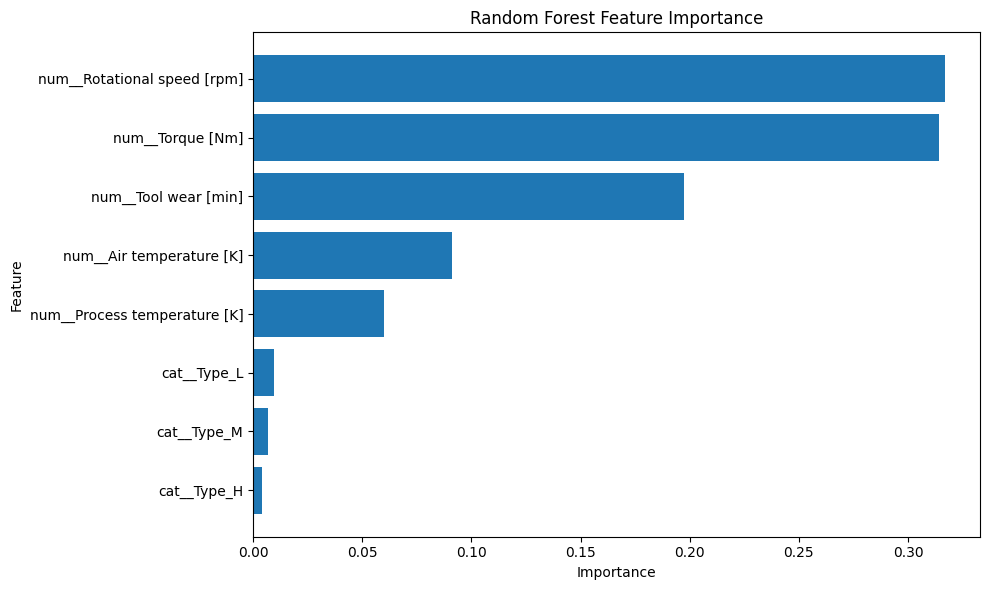

Saved files:
../reports/random_forest_feature_importance.csv
../reports/random_forest_feature_importance.png


In [15]:

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

# Save feature importance table
feature_importance_df.to_csv(
    reports_dir / "random_forest_feature_importance.csv",
    index=False
)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df["Feature"][::-1],
    feature_importance_df["Importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()

# Save plot
plt.savefig(reports_dir / "random_forest_feature_importance.png", dpi=300)

plt.show()

print("Saved files:")
print(reports_dir / "random_forest_feature_importance.csv")
print(reports_dir / "random_forest_feature_importance.png")

## 14. Feature Importance Interpretation

The feature importance plot shows that the Random Forest model mainly uses `Rotational speed [rpm]`, `Torque [Nm]`, and `Tool wear [min]` to predict machine failure. This is reasonable because these variables directly describe the mechanical operating condition of the machine.

The temperature features also contribute to the prediction, but less strongly than rotational speed, torque, and tool wear. The one-hot encoded product type features have very low importance, which means that the machine operating measurements are more useful for prediction than the product type category.

It is important to note that Random Forest feature importance does not prove causality. It only shows which features were most useful for the model when making predictions.

## 15. Final Evaluation Plots for Selected Baseline Model

To complete the model training notebook, we create final evaluation plots for the selected baseline model. These plots make it easier to understand the model performance visually. We create a confusion matrix, an ROC curve, and a precision-recall curve for the final Random Forest model using the default threshold of 0.50.

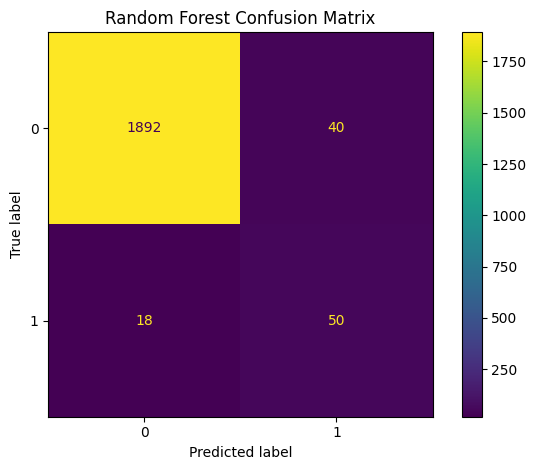

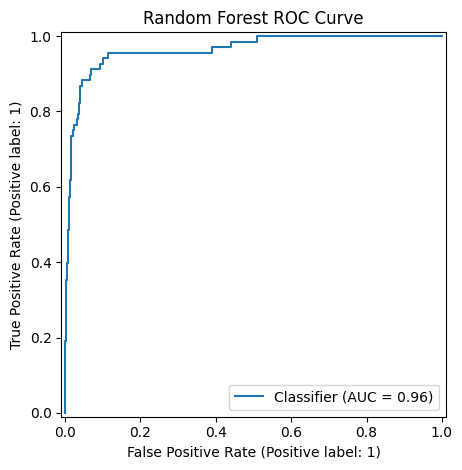

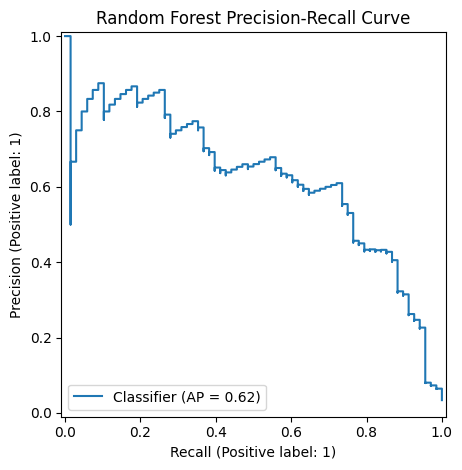

Saved files:
../reports/random_forest_confusion_matrix.png
../reports/random_forest_roc_curve.png
../reports/random_forest_precision_recall_curve.png


In [16]:
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Create reports folder if it does not exist
reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

# Predictions and probabilities for selected Random Forest model
y_test_pred_rf_default = random_forest_model.predict(X_test)
y_test_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Confusion matrix plot
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_rf_default
)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig(reports_dir / "random_forest_confusion_matrix.png", dpi=300)
plt.show()

# ROC curve plot
RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba_rf
)
plt.title("Random Forest ROC Curve")
plt.tight_layout()
plt.savefig(reports_dir / "random_forest_roc_curve.png", dpi=300)
plt.show()

# Precision-recall curve plot
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba_rf
)
plt.title("Random Forest Precision-Recall Curve")
plt.tight_layout()
plt.savefig(reports_dir / "random_forest_precision_recall_curve.png", dpi=300)
plt.show()

print("Saved files:")
print(reports_dir / "random_forest_confusion_matrix.png")
print(reports_dir / "random_forest_roc_curve.png")
print(reports_dir / "random_forest_precision_recall_curve.png")